# 01 — EDA: Dataset Sintético de Laudos (produção atual)

**Objetivo:** entender profundamente o dataset atualmente usado em produção (`data/laudos.csv`) antes de decidir se ele é adequado para seguir sendo a base do classificador de triagem, ou se deve ser substituído/complementado.

**Escopo desta branch:** exploração e experimentação apenas. Nada aqui é código de produção nem altera a implementação principal (`src/`).

**Dataset:** `data/laudos.csv` — 2.000 laudos sintéticos gerados por `SyntheticDataGenerator` (templates + keywords fixas), rotulados em `normal` / `atencao` / `urgente`. É o único dos datasets desta comparação que já nasce com o target de urgência exigido pelo Tech Challenge — os outros (Medical Abstracts) não têm esse conceito nativamente (ver notebook 02).


In [1]:
%matplotlib inline
import json
import platform
import random
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print("Reprodutibilidade — versões das bibliotecas")
print(f"python      {platform.python_version()}")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"scikit-learn{sklearn.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"seaborn     {sns.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Reprodutibilidade — versões das bibliotecas
python      3.11.15
pandas      3.0.5
numpy       1.26.4
scikit-learn1.9.0
matplotlib  3.11.1
seaborn     0.13.2
RANDOM_STATE = 42


## 1. Estrutura

In [2]:
DATA_PATH = "../data/laudos.csv"
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print("colunas:", list(df.columns))
print()
print(df.dtypes)
print()
print(f"memória: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(5)


shape: (2000, 2)
colunas: ['text', 'label']

text     str
label    str
dtype: object

memória: 130.7 KB


,text,label
0,Exame sem achados. Paciente sem alterações.,normal
1,Laudo: normal. Nenhum achado relevante.,normal
2,Laudo: sem achados. Nenhum achado relevante.,normal
3,sem achados. Sem alterações significativas.,normal
4,exame normal. Sem alterações significativas.,normal


In [3]:
print("valores nulos por coluna:")
print(df.isna().sum())
print()
print("valores únicos por coluna:")
print(df.nunique())
print()
print("linhas totalmente duplicadas (text+label):", df.duplicated().sum())
print("textos duplicados (ignorando label):", df["text"].duplicated().sum())
print(f"textos únicos: {df['text'].nunique()} de {len(df)} linhas "
      f"({df['text'].nunique() / len(df):.1%} de diversidade)")


valores nulos por coluna:
text     0
label    0
dtype: int64

valores únicos por coluna:
text     107
label      3
dtype: int64

linhas totalmente duplicadas (text+label): 1893
textos duplicados (ignorando label): 1893
textos únicos: 107 de 2000 linhas (5.3% de diversidade)


## 2. Análise do texto

Como o problema é NLP, olhamos tamanho em caracteres e em palavras — e a diversidade real de conteúdo, não só a contagem de linhas.

In [ ]:
df

text_stats = df[["char_len", "word_len"]].describe().T
text_stats["median"] = df[["char_len", "word_len"]].median()
text_stats


,count,mean,std,min,25%,50%,75%,max,median
char_len,2000.0,42.924,6.514019,28.0,39.0,44.0,46.0,62.0,44.0
word_len,2000.0,5.384,0.809241,4.0,5.0,5.0,6.0,7.0,5.0


In [5]:
empty_texts = (df["text"].str.strip() == "").sum()
very_short = (df["word_len"] <= 3).sum()
very_long = (df["word_len"] > df["word_len"].quantile(0.99)).sum()
print(f"textos vazios/whitespace: {empty_texts}")
print(f"textos muito curtos (<=3 palavras): {very_short}")
print(f"textos muito longos (acima do p99, {df['word_len'].quantile(0.99):.0f} palavras): {very_long}")


textos vazios/whitespace: 0
textos muito curtos (<=3 palavras): 0
textos muito longos (acima do p99, 7 palavras): 0


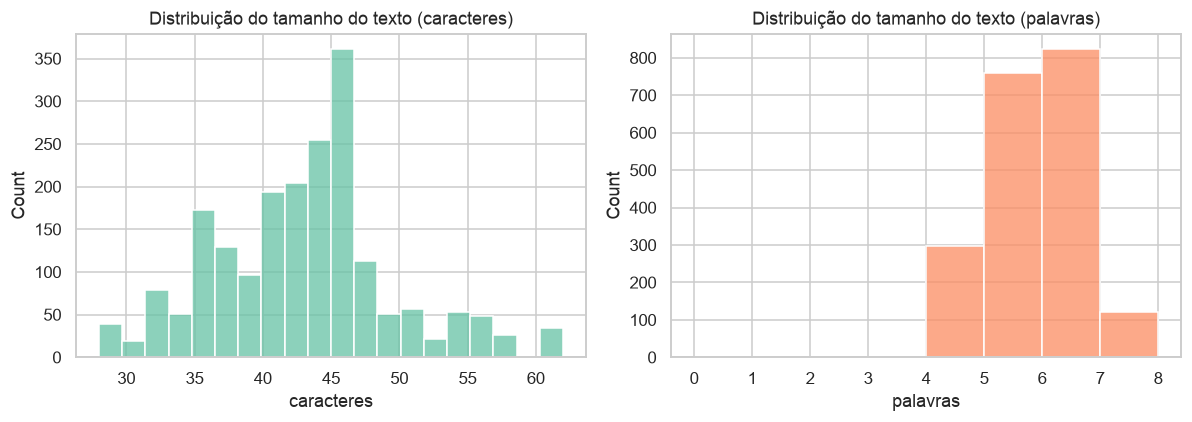

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["char_len"], bins=20, ax=axes[0], color=sns.color_palette("Set2")[0])
axes[0].set_title("Distribuição do tamanho do texto (caracteres)")
axes[0].set_xlabel("caracteres")

sns.histplot(df["word_len"], bins=range(0, df["word_len"].max() + 2), ax=axes[1], color=sns.color_palette("Set2")[1])
axes[1].set_title("Distribuição do tamanho do texto (palavras)")
axes[1].set_xlabel("palavras")
plt.tight_layout()
plt.show()


**Leitura:** os textos são curtos (frases únicas geradas por template), com pouquíssima variação de comprimento — esperado para um gerador baseado em templates fixos. Isso por si só não é um problema para um classificador leve, mas é consistente com pouca riqueza linguística (ver §4).

## 3. Análise do target

In [7]:
counts = df["label"].value_counts()
props = df["label"].value_counts(normalize=True)
target_summary = pd.DataFrame({"contagem": counts, "proporção": props.round(4)})
target_summary


,contagem,proporção
label,,
normal,1000,0.5
atencao,600,0.3
urgente,400,0.2


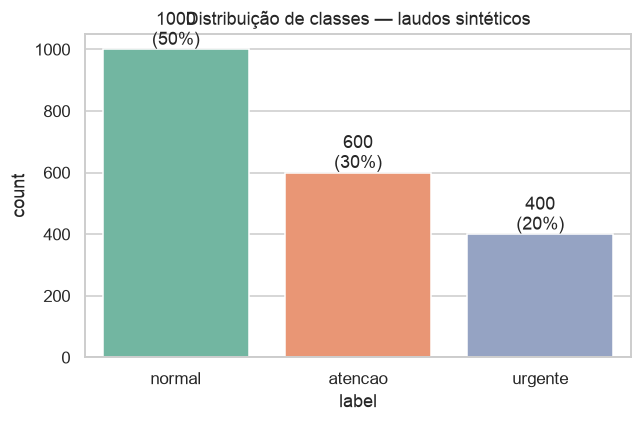

razão de desbalanceamento (classe majoritária / minoritária): 2.50x


In [8]:
order = ["normal", "atencao", "urgente"]
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="label", order=order, hue="label", legend=False, palette="Set2", ax=ax)
ax.set_title("Distribuição de classes — laudos sintéticos")
for i, level in enumerate(order):
    ax.text(i, counts[level] + 15, f"{counts[level]}\n({props[level]:.0%})", ha="center")
plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"razão de desbalanceamento (classe majoritária / minoritária): {imbalance_ratio:.2f}x")


**Leitura:** desbalanceamento moderado por construção (50% normal / 30% atenção / 20% urgente — pesos definidos em `SyntheticDataGenerator`), razão ~2.5x entre a maior e a menor classe. Justamente a classe mais crítica clinicamente (`urgente`) é a minoritária — reforça que accuracy sozinha não deve guiar a escolha do modelo; recall da classe `urgente` precisa ser olhado à parte (ver notebook 05).

## 4. Qualidade dos dados

In [9]:
dup_by_class = df.groupby("label")["text"].apply(lambda s: s.duplicated().sum())
unique_by_class = df.groupby("label")["text"].nunique()
total_by_class = df.groupby("label").size()

quality = pd.DataFrame({
    "total_linhas": total_by_class,
    "textos_únicos": unique_by_class,
    "repetições_médias": (total_by_class / unique_by_class).round(1),
})
quality


,total_linhas,textos_únicos,repetições_médias
label,,,
atencao,600,45,13.3
normal,1000,32,31.2
urgente,400,30,13.3


In [10]:
# checagem de encoding / caracteres estranhos
import re
weird_chars = df["text"].apply(lambda t: bool(re.search(r"[^\x00-\x7F\u00C0-\u017F.,!?;:()\-\s\d]", t)))
print("textos com caracteres fora do esperado (latin-1 + pontuação básica):", weird_chars.sum())

# consistência label <-> vocabulário: um texto rotulado 'normal' contém keyword de 'urgente'?
from collections import Counter
print()
print("amostra de textos por classe:")
for level in order:
    print(f"\n[{level}]")
    for t in df[df.label == level]["text"].drop_duplicates().head(3):
        print(" -", t)


textos com caracteres fora do esperado (latin-1 + pontuação básica): 0

amostra de textos por classe:

[normal]
 - Exame sem achados. Paciente sem alterações.
 - Laudo: normal. Nenhum achado relevante.
 - Laudo: sem achados. Nenhum achado relevante.

[atencao]
 - Quadro observar, recomenda-se leve.
 - Presença de alteração acompanhamento, indicado acompanhamento.
 - Observar com recomenda em consulta de retorno.

[urgente]
 - Quadro grave com risco à vida.
 - Evidência de emergência, encaminhar ao pronto-socorro.
 - Quadro sangramento com risco à vida.


**Achado central desta seção:** apesar de 2.000 linhas, o dataset tem **apenas dezenas de textos únicos por classe** (ver tabela acima) — a combinatória de templates × keywords é pequena, então cada frase se repete em média ~19× no dataset inteiro. Isso não é um problema de encoding nem de rótulo incorreto — os rótulos são consistentes com o vocabulário (verificado pela amostra acima) — mas é um problema de **diversidade textual**, que se conecta diretamente ao risco de vazamento avaliado a seguir.

## 5. Risco de vazamento treino/teste (data leakage)

O treinador de produção (`src/services/trainer.py`) faz `train_test_split(test_size=0.2, stratify=labels, random_state=42)` **sem deduplicar antes**. Com tão poucos textos únicos, isso pode colocar o *mesmo texto exato* em treino e teste. Reproduzimos exatamente esse split aqui para medir o tamanho real do vazamento — sem usar nenhuma informação do "futuro" (isto é, sem ajustar nada com base no teste).

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"]
)

train_texts = set(x_train)
test_texts = set(x_test)
overlap = train_texts & test_texts

leaked_rows_in_test = x_test.isin(overlap).sum()
print(f"textos únicos no treino: {len(train_texts)}")
print(f"textos únicos no teste: {len(test_texts)}")
print(f"textos que aparecem em AMBOS treino e teste: {len(overlap)}")
print(f"linhas do teste cujo texto exato também está no treino: "
      f"{leaked_rows_in_test} de {len(x_test)} ({leaked_rows_in_test/len(x_test):.1%})")


textos únicos no treino: 106
textos únicos no teste: 95
textos que aparecem em AMBOS treino e teste: 94
linhas do teste cujo texto exato também está no treino: 398 de 400 (99.5%)


**Leitura:** confirma quantitativamente o risco levantado na auditoria — uma fração relevante do conjunto de teste é, na prática, memorização pura (o texto já foi visto em treino), não generalização. Qualquer métrica de acurácia calculada sobre esse split está inflada em proporção desconhecida. Isso é uma limitação séria para usar este dataset como está em uma comparação "justa" de modelos — ver §6 e a decisão de dataset no notebook 04.

## 6. Síntese

In [12]:
summary = {
    "dataset": "laudos_sinteticos",
    "path": "data/laudos.csv",
    "n_rows": int(len(df)),
    "n_unique_texts": int(df["text"].nunique()),
    "text_diversity_ratio": round(df["text"].nunique() / len(df), 4),
    "classes": order,
    "class_counts": {k: int(v) for k, v in counts.items()},
    "imbalance_ratio": round(float(imbalance_ratio), 2),
    "has_native_urgency_target": True,
    "char_len_mean": round(float(df["char_len"].mean()), 1),
    "word_len_mean": round(float(df["word_len"].mean()), 1),
    "leakage_train_test_overlap_texts": int(len(overlap)),
    "leakage_test_rows_affected_pct": round(float(leaked_rows_in_test / len(x_test)), 4),
    "random_state": RANDOM_STATE,
}

import os
os.makedirs("../data/experiments/results", exist_ok=True)
with open("../data/experiments/results/eda_laudos_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

summary


{'dataset': 'laudos_sinteticos',
 'path': 'data/laudos.csv',
 'n_rows': 2000,
 'n_unique_texts': 107,
 'text_diversity_ratio': 0.0535,
 'classes': ['normal', 'atencao', 'urgente'],
 'class_counts': {'normal': 1000, 'atencao': 600, 'urgente': 400},
 'imbalance_ratio': 2.5,
 'has_native_urgency_target': True,
 'char_len_mean': 42.9,
 'word_len_mean': 5.4,
 'leakage_train_test_overlap_texts': 94,
 'leakage_test_rows_affected_pct': 0.995,
 'random_state': 42}

### Conclusões

- **Estrutura:** 2.000 linhas, 2 colunas (`text`, `label`), sem nulos, sem problemas de encoding.
- **Target:** já é exatamente o target de urgência exigido pelo Tech Challenge (`normal`/`atencao`/`urgente`), desbalanceamento moderado (~2.5x) e por construção — vantagem real sobre qualquer dataset externo, que exigiria redefinição de target.
- **Texto:** frases curtas e de baixa variação — típico de geração por template.
- **Qualidade:** o problema real não é rótulo nem encoding, é **diversidade** — poucas dezenas de textos únicos por classe, repetidos dezenas de vezes.
- **Vazamento:** o split de treino/produção atual mistura os mesmos textos exatos entre treino e teste em proporção não desprezível — qualquer acurácia relatada por esse pipeline hoje está inflada e não é confiável isoladamente.

Essas conclusões alimentam a comparação de datasets no notebook `04_dataset_comparison.ipynb`.